## Evaluation

Evaluates Hess Lab IDL, Decode and SMAP result for a single frame by rendering the points in 3D so the user can qualitatively evaluate point correspondence. 

In [19]:
import napari
from numpy import spacing
from skimage.io import imread
import glob
from wip_util import (zero_pad_index, load_iters, 
                      get_np_points, reverse_emitters, 
                      smap_csv_to_emitters, load_iter_results, 
                      print_emitters_info, filter_coordinates,
                      shift_coordinates, filter_sigmas)
import numpy as np
import decode

start_iter = 645
end_iter = 646

frames_per_iter = 250

start_frame = start_iter * frames_per_iter
end_frame = start_frame+100 #end_iter * frames_per_iter

frame_to_view = 50
xmin = 200
xmax = 600
ymin = 200
ymax = 600

In [20]:
# load frames, for this dataset sets of 250 frames are saved in tif sequences of 250 frames.  Each sequence is a single iteration.

iters_path = r'E:\Cryo-PALM Data for Brian\James processing ASCII and RAW Data files\PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)'
#iters_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/frames/'
iter_pattern = lambda id:rf'{iters_path}/3DPALM488nm_Iter_{zero_pad_index(id, 4)}_0001_ch0_CAM1_stack0000_405nm_0000000msec_*msecAbs_000x_000y_000z_0001t.tif'
frames = load_iters(start_iter, end_iter, iter_pattern)
print(frames.shape)

loading iter for id: 645
(250, 800, 800)


In [21]:
smap_input_file = r'D:\Janelia_slm_data\Janelia PALM RUN2\SMAP_Result_iter_645.csv'
#smap_input_file = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/SMAP/SMAP_Result_iter_645.csv'
smap_emitters = smap_csv_to_emitters(smap_input_file, 100, True)
print('SMAP Emitters',smap_emitters)

hesslab_input_file = r'C:\Users\bnort\work\Janelia_slm\data\James processing ASCII and RAW Data files\2a - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_with_winding_file_RAW_UNPROCESSED_PALM_LOCALIZATIONS_ASCII.hdf5'
#hesslab_input_file = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/IDL Peak Finder/2a - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_with_winding_file_RAW_UNPROCESSED_PALM_LOCALIZATIONS_ASCII.hdf5'
hesslab_emitters=decode.EmitterSet.load(hesslab_input_file)
# filter based on start and end frame
hesslab_emitters = hesslab_emitters[(hesslab_emitters.frame_ix >= start_frame) & (hesslab_emitters.frame_ix < end_frame)]
# same orientation as decode
hesslab_emitters.xyz_px = hesslab_emitters.xyz_px[:, [1,0,2]]  # Swap X and Y for rendering
print('Hesslab Emitters',hesslab_emitters)

decode_iter_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/processed-2025-06-27'
decode_iter_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2\processed-2025-06-27'
decode_emitters = load_iter_results(decode_iter_path, 645, 647)
print('DECODE emitters', decode_emitters)

SMAP Emitters EmitterSet
::num emitters: 37477
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 249
::spanned volume: [    9.036018    11.95644  -1970.      ] - [ 794.8877  795.826  2000.    ]
Hesslab Emitters EmitterSet
::num emitters: 10001
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 161250 - 161349
::spanned volume: [   3.28873   25.2394  -799.951  ] - [772.354 798.42  598.252]


Loading iterations: 100%|██████████| 2/2 [00:00<00:00, 40.82it/s]

DECODE emitters EmitterSet
::num emitters: 345830
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 161250 - 161749
::spanned volume: [-4.5627666e-01 -6.3932061e-01 -1.2588881e+03] - [ 799.507   799.4638 1246.2266]


In [22]:
decode_emitters.frame_ix = decode_emitters.frame_ix - start_frame 
hesslab_emitters.frame_ix = hesslab_emitters.frame_ix - start_frame

In [23]:
print(decode_emitters)
decode_emitters = filter_coordinates(decode_emitters, xmin = xmin, xmax=xmax, ymin=ymin, ymax=ymax, zmin=-800, zmax=800)
smap_emitters = filter_coordinates(smap_emitters, xmin = xmin, xmax=xmax, ymin=ymin, ymax=ymax, zmin=-800, zmax=800)
hesslab_emitters = filter_coordinates(hesslab_emitters, xmin = xmin, xmax=xmax, ymin=ymin, ymax=ymax, zmin=-800, zmax=800)
print(decode_emitters)

decode_emitters = shift_coordinates(decode_emitters, -xmin, -ymin, 0)
smap_emitters = shift_coordinates(smap_emitters, -xmin, -ymin, 0)
hesslab_emitters = shift_coordinates(hesslab_emitters, -xmin, -ymin, 0)

EmitterSet
::num emitters: 345830
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [-4.5627666e-01 -6.3932061e-01 -1.2588881e+03] - [ 799.507   799.4638 1246.2266]
EmitterSet
::num emitters: 49015
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [ 200.98706  200.35886 -799.95026] - [599.9868  599.98975 799.94165]


In [24]:
print(decode_emitters)
decode_emitters = filter_sigmas(decode_emitters, x_sig_max = 100, y_sig_max = 100, z_sig_max = 300, prob_min=0.50, phot_min=0)
smap_emitters = filter_sigmas(smap_emitters, x_sig_max = 100, y_sig_max = 100, z_sig_max = 300, prob_min=0.0, phot_min=0)
hesslab_emitters = filter_sigmas(hesslab_emitters, x_sig_max = 500, y_sig_max = 500, z_sig_max = 1000, prob_min=0.0, phot_min=0)
print(decode_emitters)


EmitterSet
::num emitters: 49015
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [ 9.8706055e-01  3.5885620e-01 -7.9995026e+02] - [399.98682 399.98975 799.94165]
EmitterSet
::num emitters: 37372
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [   1.0055084    1.4617767 -799.8079   ] - [399.9751  399.98975 799.94165]


In [25]:
hesslab_emitters_ = hesslab_emitters[(hesslab_emitters.frame_ix == frame_to_view)]
print(hesslab_emitters_)

decode_emitters_ = decode_emitters[(decode_emitters.frame_ix == frame_to_view)]
print(decode_emitters_)

EmitterSet
::num emitters: 30
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50 - 50
::spanned volume: [  24.126   95.59  -790.287] - [377.647 377.805 376.698]
EmitterSet
::num emitters: 79
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50 - 50
::spanned volume: [  23.847198    5.353607 -789.636   ] - [395.19812 376.86157 791.0313 ]


In [26]:
import torch

decode_emitters_.xyz_nm.dtype, hesslab_emitters_.xyz_nm.dtype
hesslab_emitters_.xyz_nm = hesslab_emitters_.xyz_nm.to(torch.float32)

In [27]:
matcher = decode.evaluation.match_emittersets.GreedyHungarianMatching(match_dims=3, dist_lat=200, dist_ax=5000.)  # always in nm

tp, fp, fn, tp_match = matcher.forward(decode_emitters_, hesslab_emitters_)  # outputs true positives, false positives, false negatives, matched ground truth

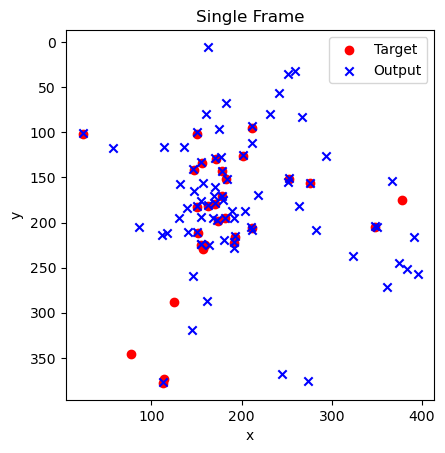

In [28]:
import matplotlib.pyplot as plt

# plot on a selected frame
decode.plot.PlotCoordinates(pos_tar=hesslab_emitters_.xyz_px, 
                            pos_out=decode_emitters_.xyz_px).plot()
plt.legend()
plt.title('Single Frame')
plt.show()

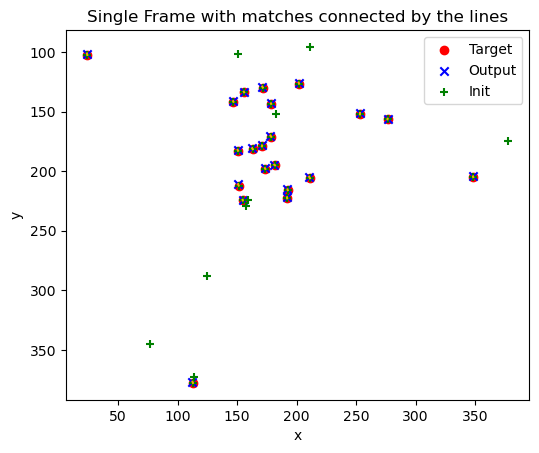

In [29]:

# plot
# plot on a selected frame
decode.plot.PlotCoordinates(pos_tar=tp_match.xyz_px, 
                            pos_out=tp.xyz_px,
                            pos_ini=hesslab_emitters_.xyz_px,
                            match_lines=True).plot()

plt.legend()
plt.title('Single Frame with matches connected by the lines')
plt.show()

In [13]:
decode_points = get_np_points(decode_emitters, 0, 100, True)
print(decode_points.shape)
decode_points = decode_points[decode_points[:,0] == frame_to_view]
print(decode_points.shape)
decode_points_t = decode_points[:,1:4]
decode_points_t = decode_points_t[:, [2, 0, 1]]  # Reorder to (z, y, x)

print(smap_emitters)
smap_points = get_np_points(smap_emitters, 0, 100, True)
print(smap_points.shape)
smap_points = smap_points[smap_points[:,0] == frame_to_view]
print(smap_points.shape)
smap_points_t = smap_points[:,1:4]
smap_points_t = smap_points_t[:, [2, 0, 1]]  # Reorder to (z, y, x)

print(hesslab_emitters)
hesslab_points = get_np_points(hesslab_emitters, 0, 100, True)
print(hesslab_points.shape)

hesslab_points = hesslab_points[hesslab_points[:,0] == frame_to_view]
print(hesslab_points.shape)
hesslab_points_t = hesslab_points[:,1:4]
hesslab_points_t = hesslab_points_t[:, [2, 0, 1]]  # Reorder to (z, y, x)


(10556, 4)
(110, 4)
EmitterSet
::num emitters: 35361
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 249
::spanned volume: [    9.036018    11.95644  -1970.      ] - [ 794.8877  795.826  1926.812 ]
(13981, 4)
(142, 4)
EmitterSet
::num emitters: 10001
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 99
::spanned volume: [   3.28873   25.2394  -799.951  ] - [772.354 798.42  598.252]
(10001, 4)
(106, 4)


In [14]:
viewer = napari.Viewer()
viewer.add_image(frames[frame_to_view, ymin:ymax, xmin:xmax])

scale = [1, 1, 1]
size = 3
viewer.add_points(decode_points_t, size=size, face_color='blue', name='decode emitters (t)', scale=scale)
viewer.add_points(hesslab_points_t, size=size, face_color='red', name='hesslab emitters (t)', scale=scale)
viewer.add_points(smap_points_t, size=size, face_color='green', name='smap emitters (t)', scale=scale)

<Points layer 'smap emitters (t)' at 0x21aa226dd90>